# Cangjie `threadScope` vs plain `spawn`

This notebook presents the focused benchmark in `minimal-benchmark/`. It compares end-to-end task creation and result collection using identical work on both paths.

> **Result:** CPU-bound performance is indistinguishable at the 3% threshold. For trivial tasks, plain `spawn` is materially cheaper because `threadScope` also provides completion-order delivery, scoped cleanup, cancellation, and failure propagation.

## Run context and method

- Machine: Apple M4 Mac mini, 10 cores (4 performance + 6 efficiency), 16 GB RAM.
- Compiler: locally built Cangjie cjnative toolchain; benchmark compiled with `-O2`.
- Source data: `results/cangjie-minimal-benchmark.csv`.
- Each case receives 3 warmups followed by 15 recorded samples.
- The report discards the two fastest and two slowest samples and uses the median of the remaining 11.
- Execution order alternates between `threadScope` and `spawn` on every measured iteration.
- Checksums must remain stable and match between implementations.

The CPU workload divides a fixed 20 million deterministic integer iterations among the requested task count. The scheduling workload executes exactly 8,192 tasks per measurement; each task only returns its index, deliberately exposing task-management overhead.

In [1]:
from collections import defaultdict
from pathlib import Path
import csv
import statistics

candidates = [
    Path("results/cangjie-minimal-benchmark.csv"),
    Path("../results/cangjie-minimal-benchmark.csv"),
]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Run tools/run_minimal_cangjie_benchmark.sh first")

with data_path.open(encoding="utf-8") as handle:
    reader = csv.DictReader(
        line for line in handle
        if line.startswith("language,") or line.startswith("cangjie,")
    )
    measurements = [
        {
            "benchmark": row["benchmark"],
            "workload": int(row["total_workload"]),
            "task_count": int(row["task_count"]),
            "elapsed_us": int(row["elapsed_us"]),
            "checksum": int(row["checksum"]),
        }
        for row in reader
    ]

grouped = defaultdict(list)
for row in measurements:
    grouped[(row["benchmark"], row["task_count"])].append(row)

summary = {}
for key, rows in grouped.items():
    elapsed = sorted(row["elapsed_us"] for row in rows)[2:-2]
    summary[key] = {
        "samples": len(rows),
        "workload": rows[0]["workload"],
        "median_us": int(statistics.median(elapsed)),
        "min_us": min(elapsed),
        "max_us": max(elapsed),
        "checksums": {row["checksum"] for row in rows},
    }

pairs = {
    "structured_thread_scope": "spawn_cpu",
    "scheduling_cost": "spawn_scheduling_cost",
}
assert all(item["samples"] == 15 for item in summary.values())
for (benchmark, task_count), item in summary.items():
    if benchmark in pairs:
        other = summary[(pairs[benchmark], task_count)]
        assert len(item["checksums"]) == len(other["checksums"]) == 1
        assert item["checksums"] == other["checksums"]

print(f"Loaded {len(measurements)} measurements across {len(summary)} benchmark cases.")
print("All cases contain 15 samples; paired checksums match.")

Loaded 330 measurements across 22 benchmark cases.
All cases contain 15 samples; paired checksums match.


## CPU-bound results

| Tasks | `threadScope` median | `spawn` median | `spawn/threadScope` | Verdict |
| ---: | ---: | ---: | ---: | :--- |
| 1 | 64.908 ms | 64.891 ms | 1.000× | tied |
| 2 | 32.575 ms | 32.547 ms | 0.999× | tied |
| 4 | 18.201 ms | 18.289 ms | 1.005× | tied |
| 8 | 12.308 ms | 12.280 ms | 0.998× | tied |
| 16 | 11.939 ms | 11.897 ms | 0.996× | tied |
| 32 | 10.108 ms | 10.074 ms | 0.997× | tied |

Every difference is below 0.5%, well inside the 3% tie threshold. Once tasks perform meaningful work, `threadScope` bookkeeping is hidden by the computation. Both APIs show the same scaling shape and flatten after eight tasks on this heterogeneous 10-core machine.

In [2]:
print("tasks  threadScope_ms  spawn_ms  spawn/threadScope")
for task_count in [1, 2, 4, 8, 16, 32]:
    scoped = summary[("structured_thread_scope", task_count)]["median_us"]
    spawned = summary[("spawn_cpu", task_count)]["median_us"]
    print(f"{task_count:5d}  {scoped / 1000:14.3f}  {spawned / 1000:8.3f}  {spawned / scoped:17.3f}")

tasks  threadScope_ms  spawn_ms  spawn/threadScope
    1          64.908    64.891              1.000
    2          32.575    32.547              0.999
    4          18.201    18.289              1.005
    8          12.308    12.280              0.998
   16          11.939    11.897              0.996
   32          10.108    10.074              0.997


## Trivial-task scheduling results

| Tasks per group | Groups per measurement | `threadScope` median | `spawn` median | `threadScope/spawn` |
| ---: | ---: | ---: | ---: | ---: |
| 1 | 8,192 | 17.420 ms | 5.008 ms | 3.48× |
| 8 | 1,024 | 7.256 ms | 3.794 ms | 1.91× |
| 64 | 128 | 5.560 ms | 1.662 ms | 3.35× |
| 1,024 | 8 | 6.899 ms | 1.502 ms | 4.59× |
| 8,192 | 1 | 7.588 ms | 1.591 ms | 4.77× |

All rows execute exactly 8,192 tasks. Plain `spawn` is cheaper when task bodies do essentially nothing. At one large group of 8,192 tasks, the median end-to-end cost is about **194 ns/task** for `spawn` and **926 ns/task** for `threadScope`.

In [3]:
print("tasks/group  groups  threadScope_ns/task  spawn_ns/task  threadScope/spawn")
for task_count in [1, 8, 64, 1024, 8192]:
    scoped = summary[("scheduling_cost", task_count)]
    spawned = summary[("spawn_scheduling_cost", task_count)]
    workload = scoped["workload"]
    scoped_ns = scoped["median_us"] * 1000 / workload
    spawned_ns = spawned["median_us"] * 1000 / workload
    print(
        f"{task_count:11d}  {workload // task_count:6d}"
        f"  {scoped_ns:19.1f}  {spawned_ns:13.1f}  {scoped_ns / spawned_ns:17.2f}"
    )

tasks/group  groups  threadScope_ns/task  spawn_ns/task  threadScope/spawn
          1    8192               2126.5          611.3               3.48
          8    1024                885.7          463.1               1.91
         64     128                678.7          202.9               3.35
       1024       8                842.2          183.3               4.59
       8192       1                926.3          194.2               4.77


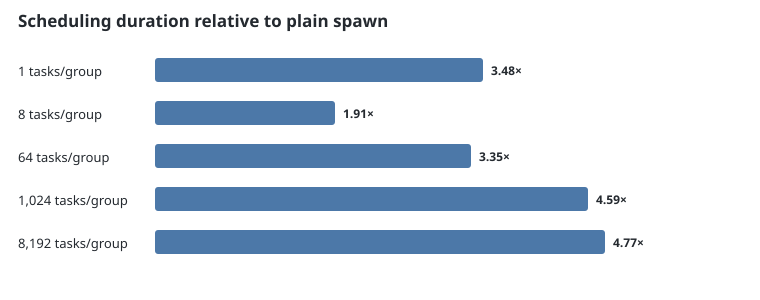

In [4]:
class SVGChart:
    def __init__(self, svg):
        self.svg = svg
    def _repr_svg_(self):
        return self.svg

def ratio_chart(values):
    width, left, bar_width = 760, 155, 450
    height = 85 + 43 * len(values)
    maximum = max(ratio for _, ratio in values)
    parts = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}'>",
        "<style>text{font-family:sans-serif;fill:#24292f}.title{font-size:17px;font-weight:600}.label{font-size:13px}.value{font-size:12px;font-weight:600}.bar{fill:#4c78a8}</style>",
        "<text x='18' y='27' class='title'>Scheduling duration relative to plain spawn</text>",
    ]
    for index, (label, ratio) in enumerate(values):
        y = 58 + index * 43
        rendered_width = ratio / maximum * bar_width
        parts.append(f"<text x='18' y='{y + 18}' class='label'>{label}</text>")
        parts.append(f"<rect x='{left}' y='{y}' width='{rendered_width:.0f}' height='24' rx='3' class='bar'/>")
        parts.append(f"<text x='{left + rendered_width + 8:.0f}' y='{y + 17}' class='value'>{ratio:.2f}×</text>")
    parts.append("</svg>")
    return SVGChart("\n".join(parts))

scheduling_ratios = []
for task_count in [1, 8, 64, 1024, 8192]:
    scoped = summary[("scheduling_cost", task_count)]["median_us"]
    spawned = summary[("spawn_scheduling_cost", task_count)]["median_us"]
    scheduling_ratios.append((f"{task_count:,} tasks/group", scoped / spawned))
ratio_chart(scheduling_ratios)

## Interpretation

`threadScope` is built on `spawn`, so it cannot beat raw spawning on bookkeeping alone. Its additional cost buys structured lifetime management, completion-order result iteration, cancellation of sibling work after failure, and centralized failure propagation.

The practical conclusion is workload-dependent:

- For substantial independent CPU work, prefer the clearer or safer API—the measured runtime is the same.
- For extremely small tasks where task-management throughput dominates, raw `spawn` is cheaper. In practice, batching such work is likely more valuable than choosing either primitive.
- These minimal benchmarks intentionally avoid heterogeneous task durations and downstream pipelines. Those scenarios exercise `threadScope`'s completion-order semantics rather than pure overhead.

Do not interpret the scheduling percentages as expected whole-application speedups: the scheduling task body performs almost no work.

## Reproduce

From the repository root, with the Cangjie toolchain already sourced:

```bash
bash tools/run_minimal_cangjie_benchmark.sh
.venv/bin/python tools/compare_benchmarks.py results/cangjie-minimal-benchmark.csv
```

The notebook analysis itself imports only Python standard-library modules. Jupyter is required only to open and re-execute the notebook interactively.